In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages #a reducer used to add messages to the state rather than replacing
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

import os 
import sys
sys.path.append(os.path.abspath(".."))
from dotenv import load_dotenv
load_dotenv()

c:\Users\davis\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


True

In [2]:
class State(TypedDict):
    #Messages have the type "list". The "add_messages" function
    #in the annotation defines how this state key should be updated
    #(in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

In [3]:
llm = ChatOpenAI(
    model = "gpt-3.5-turbo"
)

In [4]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)
tool.invoke("What is Langgraph")

{'query': 'What is Langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph/',
   'title': 'What is LangGraph',
   'content': 'LangGraph is an open-source framework built by LangChain that streamlines the creation and management of AI agent workflows. At its core, LangGraph combines large language models (LLMs) with graph-based architectures allowing developers to map, organize and optimize how AI agents interact and make decisions. By treating workflows as interconnected nodes and edges, LangGraph offers a scalable, transparent and developer-friendly way to design advanced AI systems ranging from simple chatbots to multi-agent system. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. By designing workflows, users combine multiple nodes into powerful, dynamic AI processes. * ****langgraph:**** Framework for building graph-based

In [5]:
#custom function
def multiply(a:int, b:int) -> int:
    """ Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
    int: output int
    """
    return a*b

In [6]:
tools = [tool, multiply]

In [7]:
llm_with_tools = llm.bind_tools(tools)

In [8]:
#tool definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [9]:
#Graph
graph_builder = StateGraph(State)

#add nodes
graph_builder.add_node("tools_calling_llm", tool_calling_llm)
graph_builder.add_node("tools", ToolNode(tools))

#add edges
graph_builder.add_edge(START, "tools_calling_llm")
graph_builder.add_conditional_edges(
    "tools_calling_llm",
    tools_condition
)
#if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
#if the latest message (result) from assistant is not a tool call -> tools_conditon routes to END
graph_builder.add_edge("tools", "tools_calling_llm")

In [10]:
memory = MemorySaver()

In [11]:
#compile the graph
graph = graph_builder.compile(checkpointer=memory)

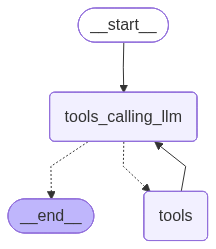

In [12]:
#visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))

except Exception:
    pass

In [14]:
config = {"configurable": {"thread_id": "1"}}

response = graph.invoke({"messages": "Hi my name is Sora"}, config=config)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi my name is Sora
================================== Ai Message ==================================

Hello Sora! How can I assist you today?


In [15]:
response = graph.invoke({"messages": "Hey, what is my name?"}, config=config)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi my name is Sora
================================== Ai Message ==================================

Hello Sora! How can I assist you today?
================================ Human Message =================================

Hey, what is my name?
================================== Ai Message ==================================

Your name is Sora. Is there anything else you would like to know or ask about?


In [16]:
response = graph.invoke({"messages": "Do you remember my name"}, config=config)

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi my name is Sora
================================== Ai Message ==================================

Hello Sora! How can I assist you today?
================================ Human Message =================================

Hey, what is my name?
================================== Ai Message ==================================

Your name is Sora. Is there anything else you would like to know or ask about?
================================ Human Message =================================

Do you remember my name
================================== Ai Message ==================================

Yes, I remember your name. It's Sora. How can I help you today, Sora?
